In [79]:
# 导入库
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

In [80]:
# 读入数据
data=pd.read_csv("Delivery.csv")

In [82]:
# 根据梯度求点
def stepGradient(k0,k1,k2,data,learning_rate):
    import pandas as pd
    xdata=data.iloc[:,:2]
    ydata=data.iloc[:,-1]
    k0_gradient = 0
    k1_gradient = 0
    k2_gradient = 0
    N = float(data.shape[0])
    for i in range(data.shape[0]):
        x1=xdata.iat[i,0]
        x2=xdata.iat[i,1]
        y=ydata[i]
        #求偏导
        k0_gradient += -(2/N) * (y-k0-k1*x1-k2*x2)
        k1_gradient += -(2/N) * (y-k0-k1*x1-k2*x2)*x1
        k2_gradient += -(2/N) * (y-k0-k1*x1-k2*x2)*x2
    #得到新的点坐标
    new_k0 = k0 - (learning_rate * k0_gradient)
    new_k1 = k1 - (learning_rate * k1_gradient)
    new_k2 = k2 - (learning_rate * k2_gradient)
    return [new_k0,new_k1,new_k2]

In [83]:
#学习函数
def gradient_descent_runner(data,starting_k0,starting_k1,starting_k2,learning_num,learning_rate):
    k0 = starting_k0
    k1 = starting_k1
    k2 = starting_k2
    for i in range(learning_num):
        k0,k1,k2= stepGradient(k0,k1,k2,data, learning_rate)#产生新的点 带入新点继续学习
    return [k0,k1,k2]

In [92]:
#初始值
initial_k0 = 0 
initial_k1 = 0
initial_k2 = 0
learning_num = 1000#学习次数
learning_rate=0.0001 #学习率
[k0,k1,k2] = gradient_descent_runner(data,initial_k0,initial_k1,initial_k2,learning_num,learning_rate)

In [93]:
print([k0,k1,k2])

[0.017991588339449614, 0.07607374497590792, 0.14456141610812911]


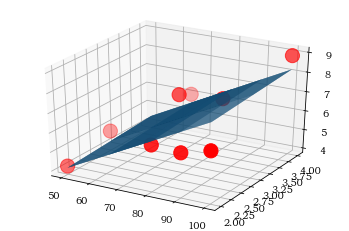

In [94]:
# 画图
x0=xdata.iloc[:,0]
x1=xdata.iloc[:,1]
ax=plt.figure().add_subplot(111,projection="3d")
ax.scatter(x0,x1,ydata,c='r',marker='o',s=200)
x0,x1=np.meshgrid(x0,x1)
z=k0+x0*k1+x1*k2
ax.plot_surface(x0,x1,z,alpha=0.2)
plt.show()